In [41]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier


In [42]:
DATA_PATH = "kidney_disease.csv"

OUTPUT_DIR = "kidney_research_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

TEST_SIZE = 0.20

N_SPLITS = 5

In [96]:
print("\n" + "=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv("/Users/kratikaneekhra_01/Documents/Smart Health Monitoring /Dataset/kidney_disease.csv")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)



LOADING DATASET

Dataset Shape:
(400, 26)

First 5 Rows:
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]

Column Name

In [97]:
print("\n" + "=" * 70)
print("BASIC DATASET INFORMATION")
print("=" * 70)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Info:")
print(df.info())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())




BASIC DATASET INFORMATION

Number of Rows: 400
Number of Columns: 26

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv   

In [98]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())



Cleaned Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [99]:
for col in df.select_dtypes(include="object").columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "\t": np.nan,
            "": np.nan,
            "nan": np.nan,
            "none": np.nan,
            "?": np.nan
        })
    )

In [100]:
TARGET = "classification"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

print("\nTarget Column:", TARGET)

print("\nTarget Distribution:")
print(df[TARGET].value_counts(dropna=False))

print("\nTarget Percentage:")
print(df[TARGET].value_counts(normalize=True, dropna=False) * 100)



Target Column: classification

Target Distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64

Target Percentage:
classification
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64


In [101]:
df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.strip()
    .str.lower()
)

df[TARGET] = df[TARGET].replace({
    "ckd\t": "ckd",
    "notckd\t": "notckd",
    "ckd": "ckd",
    "notckd": "notckd"
})

df = df[df[TARGET].isin(["ckd", "notckd"])].copy()


In [102]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df[TARGET])

print("\nTarget Classes:")
print(label_encoder.classes_)

print("\nEncoded Target Distribution:")
print(pd.Series(y).value_counts())


Target Classes:
['ckd' 'notckd']

Encoded Target Distribution:
0    250
1    150
Name: count, dtype: int64


In [103]:
possible_id_columns = [
    "id",
    "patient_id",
    "patientid",
    "record_id"
]

id_columns = [
    col for col in possible_id_columns
    if col in df.columns
]

if id_columns:
    print("\nRemoving ID Columns:", id_columns)
    df = df.drop(columns=id_columns)


Removing ID Columns: ['id']


In [104]:
for col in df.columns:
    if col == TARGET:
        continue

    if df[col].dtype == "object":

        converted = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        valid_ratio = converted.notna().mean()

        if valid_ratio >= 0.70:
            df[col] = converted

In [105]:
y = label_encoder.fit_transform(df[TARGET])

X = df.drop(columns=[TARGET]).copy()


In [106]:
print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print("Rows:", len(df))
print("Features:", X.shape[1])

print("\nFeature Types:")
print(X.dtypes.value_counts())

print("\nMissing Values:")
missing_summary = X.isnull().sum().sort_values(ascending=False)

print(missing_summary)



FINAL DATASET SUMMARY
Rows: 400
Features: 24

Feature Types:
str        13
float64    11
Name: count, dtype: int64

Missing Values:
rbc      152
rc       131
wc       106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
ba         4
pcc        4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


In [107]:
cleaned_df = X.copy()

cleaned_df[TARGET] = label_encoder.inverse_transform(y)

cleaned_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "kidney_cleaned_dataset.csv"
    ),
    index=False
)


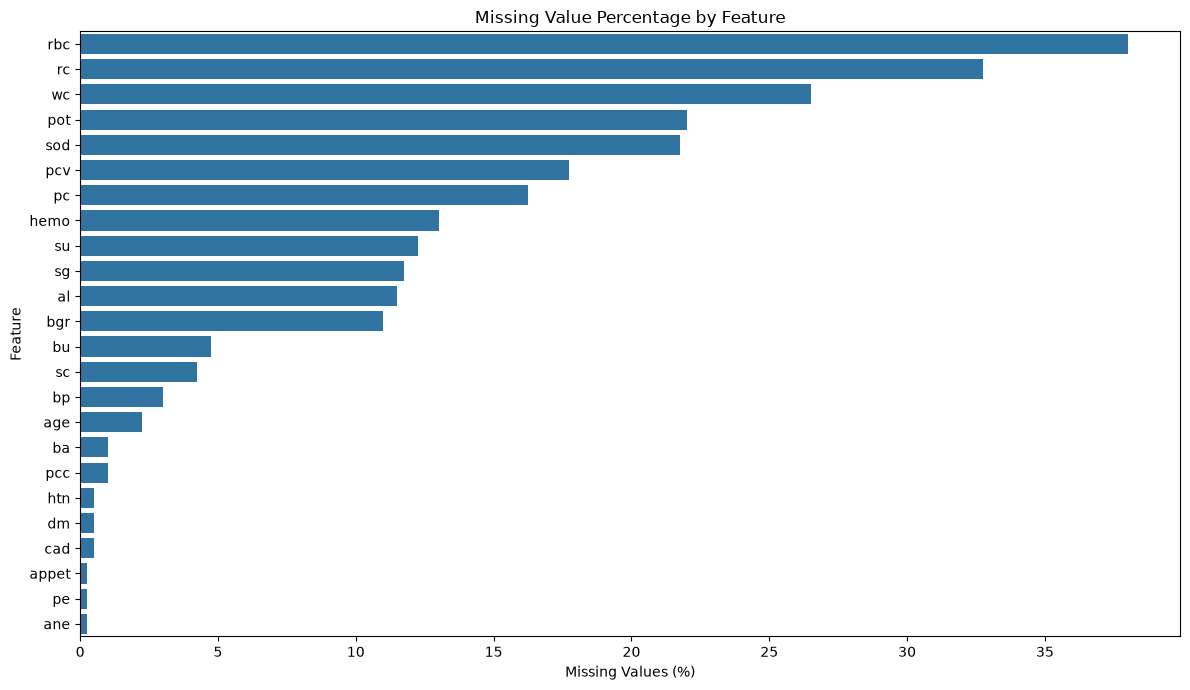

In [108]:
plt.figure(figsize=(12, 7))

missing_percent = (
    X.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[
    missing_percent > 0
]

if len(missing_percent) > 0:

    sns.barplot(
        x=missing_percent.values,
        y=missing_percent.index
    )

    plt.xlabel("Missing Values (%)")
    plt.ylabel("Feature")
    plt.title("Missing Value Percentage by Feature")
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "01_missing_values.png"
        ),
        dpi=300
    )

plt.show()


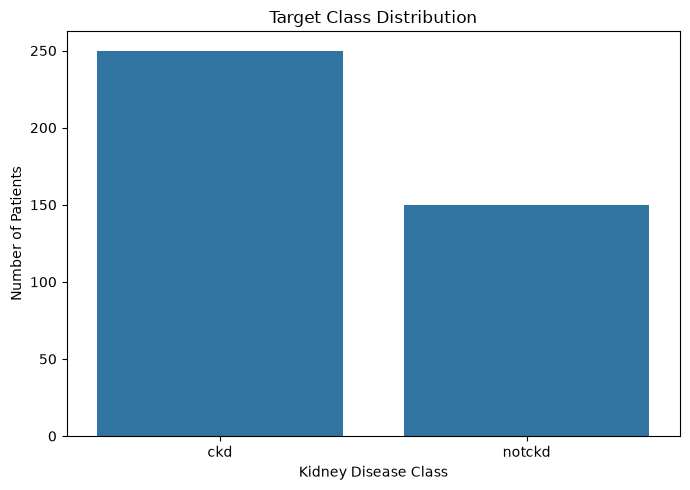

In [109]:
plt.figure(figsize=(7, 5))

target_counts = df[TARGET].value_counts()

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.xlabel("Kidney Disease Class")
plt.ylabel("Number of Patients")
plt.title("Target Class Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_class_distribution.png"
    ),
    dpi=300
)

plt.show()


In [110]:
numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

if len(numeric_columns) > 0:

    numeric_summary = X[numeric_columns].describe().T

    numeric_summary.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "numeric_summary.csv"
        )
    )

    print("\nNumeric Summary:")
    print(numeric_summary)


Numeric Summary:
      count        mean        std     min     25%     50%     75%      max
age   391.0   51.483376  17.169714   2.000   42.00   55.00   64.50   90.000
bp    388.0   76.469072  13.683637  50.000   70.00   80.00   80.00  180.000
sg    353.0    1.017408   0.005717   1.005    1.01    1.02    1.02    1.025
al    354.0    1.016949   1.352679   0.000    0.00    0.00    2.00    5.000
su    351.0    0.450142   1.099191   0.000    0.00    0.00    0.00    5.000
bgr   356.0  148.036517  79.281714  22.000   99.00  121.00  163.00  490.000
bu    381.0   57.425722  50.503006   1.500   27.00   42.00   66.00  391.000
sc    383.0    3.072454   5.741126   0.400    0.90    1.30    2.80   76.000
sod   313.0  137.528754  10.408752   4.500  135.00  138.00  142.00  163.000
pot   312.0    4.627244   3.193904   2.500    3.80    4.40    4.90   47.000
hemo  348.0   12.526437   2.912587   3.100   10.30   12.65   15.00   17.800


In [111]:
categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

categorical_summary = {}

for col in categorical_columns:

    categorical_summary[col] = (
        X[col]
        .value_counts(dropna=False)
        .to_dict()
    )

categorical_summary_df = pd.DataFrame(
    categorical_summary
).T

categorical_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "categorical_summary.csv"
    )
)


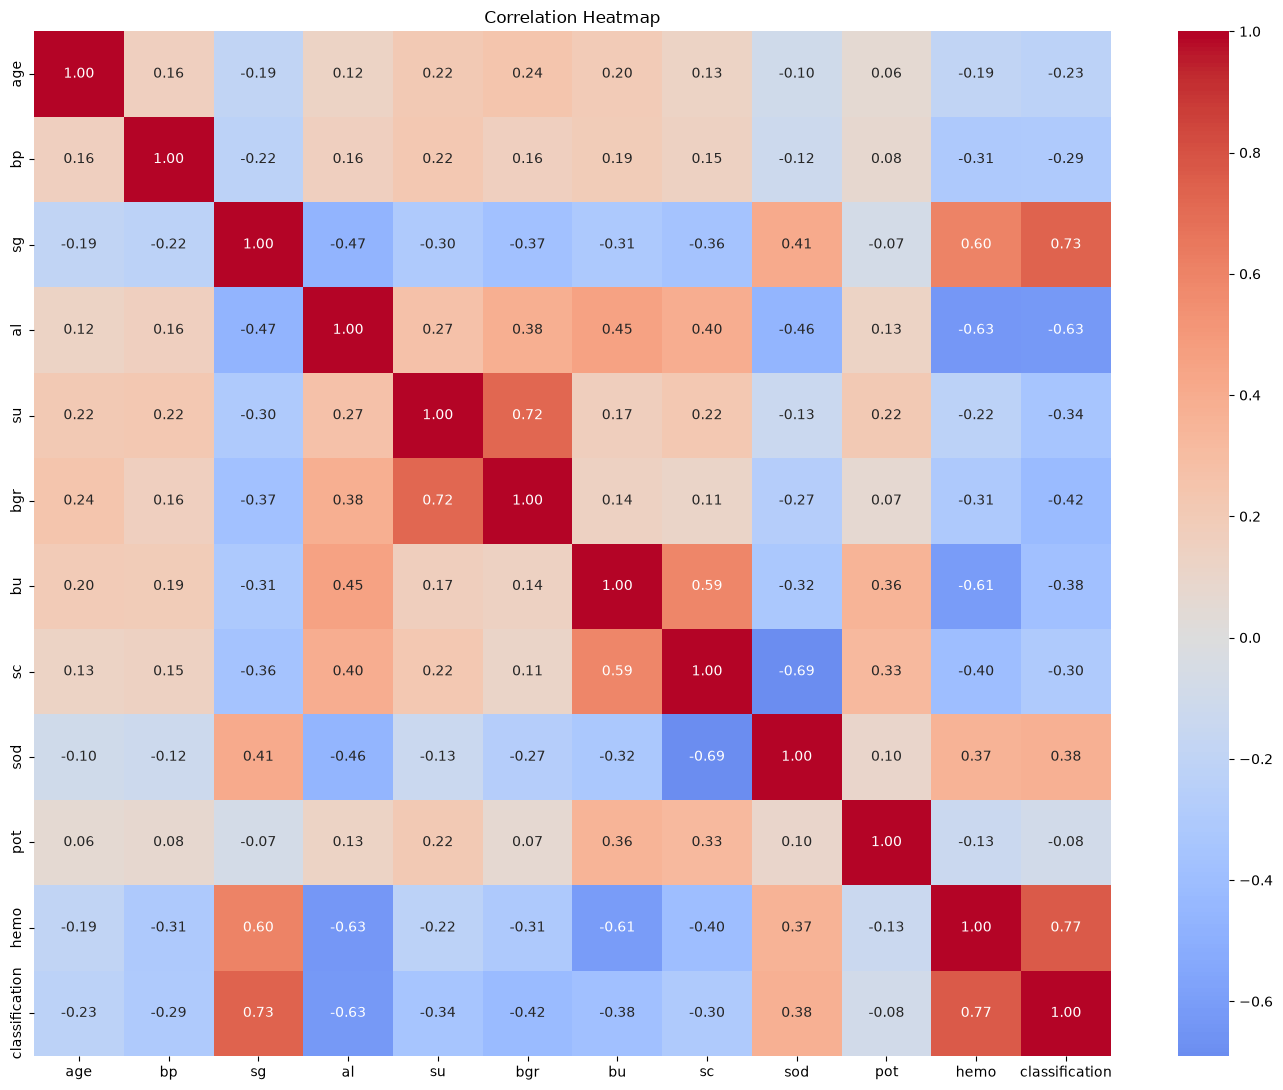


Feature-Target Correlations:
hemo    0.768919
sg      0.732163
al     -0.627090
bgr    -0.419672
bu     -0.380605
sod     0.375674
su     -0.344070
sc     -0.299969
bp     -0.294077
age    -0.227268
pot    -0.084541
Name: classification, dtype: float64


In [112]:
if len(numeric_columns) > 1:

    correlation_data = X[numeric_columns].copy()

    correlation_data[TARGET] = y

    correlation_matrix = correlation_data.corr()

    plt.figure(figsize=(14, 11))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "03_correlation_heatmap.png"
        ),
        dpi=300
    )

    plt.show()

    target_correlations = (
        correlation_matrix[TARGET]
        .drop(TARGET)
        .sort_values(
            key=lambda x: abs(x),
            ascending=False
        )
    )

    print("\nFeature-Target Correlations:")
    print(target_correlations)

    target_correlations.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "feature_target_correlations.csv"
        )
    )



In [113]:
if len(numeric_columns) > 0:

    for col in numeric_columns:

        plt.figure(figsize=(7, 5))

        sns.histplot(
            data=df,
            x=col,
            kde=True
        )

        plt.title(
            f"Distribution of {col}"
        )

        plt.tight_layout()

        safe_name = (
            col.replace("/", "_")
            .replace(" ", "_")
        )

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                f"distribution_{safe_name}.png"
            ),
            dpi=300
        )

        plt.close()


In [114]:
if len(numeric_columns) > 0:

    important_features = numeric_columns[:12]

    for col in important_features:

        plt.figure(figsize=(7, 5))

        sns.boxplot(
            data=df,
            x=TARGET,
            y=col
        )

        plt.title(
            f"{col} by Kidney Disease Class"
        )

        plt.tight_layout()

        safe_name = (
            col.replace("/", "_")
            .replace(" ", "_")
        )

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                f"boxplot_{safe_name}.png"
            ),
            dpi=300
        )

        plt.close()

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print(
    "Training Class Distribution:",
    np.bincount(y_train)
)

print(
    "Testing Class Distribution:",
    np.bincount(y_test)
)



TRAIN TEST SPLIT
Training Samples: 320
Testing Samples: 80
Training Class Distribution: [200 120]
Testing Class Distribution: [50 30]


In [116]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)



Numeric Features:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Categorical Features:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [117]:
numeric_pipeline = Pipeline(
    steps=[
        ( "imputer", SimpleImputer(  strategy="median"     )
        ),
        ( "scaler",StandardScaler() )
    ]
)

In [118]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


In [119]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


In [120]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "ANN":
        MLPClassifier(
            max_iter=1000,
            random_state=RANDOM_STATE,
            early_stopping=True
        )
}



In [121]:
param_grids = {

    "Logistic Regression": {

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__solver": [
            "liblinear",
            "lbfgs"
        ]
    },


    "Decision Tree": {

        "model__max_depth": [
            3,
            5,
            7,
            10,
            None
        ],

        "model__min_samples_split": [
            2,
            5,
            10
        ],

        "model__min_samples_leaf": [
            1,
            2,
            4
        ]
    },


    "Random Forest": {

        "model__n_estimators": [
            100,
            200,
            300
        ],

        "model__max_depth": [
            None,
            5,
            10,
            15
        ],

        "model__min_samples_split": [
            2,
            5
        ],

        "model__min_samples_leaf": [
            1,
            2
        ]
    },


    "XGBoost": {

        "model__n_estimators": [
            100,
            200,
            300
        ],

        "model__max_depth": [
            2,
            3,
            5
        ],

        "model__learning_rate": [
            0.01,
            0.05,
            0.1
        ],

        "model__subsample": [
            0.8,
            1.0
        ],

        "model__colsample_bytree": [
            0.8,
            1.0
        ]
    },


    "ANN": {

        "model__hidden_layer_sizes": [
            (32,),
            (64,),
            (64, 32)
        ],

        "model__activation": [
            "relu",
            "tanh"
        ],

        "model__alpha": [
            0.0001,
            0.001,
            0.01
        ],

        "model__learning_rate_init": [
            0.001,
            0.01
        ]
    }
}


In [122]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [123]:
best_estimators = {}
best_parameters = {}
cv_results = {}
test_results = {}
classification_reports = {}


In [145]:
for model_name, model in models.items():

    print("\n" + "=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(
        X_train,
        y_train
    )

    best_model = grid.best_estimator_

    best_estimators[model_name] = best_model

    best_parameters[model_name] = (
        grid.best_params_
    )

    print("\nBest Parameters:")
    

    print(
        "\nBest CV ROC-AUC:",
        grid.best_score_
    )




TRAINING: Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:

Best CV ROC-AUC: 0.9997916666666666

TRAINING: Decision Tree
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best Parameters:

Best CV ROC-AUC: 0.9829166666666668

TRAINING: Random Forest
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters:

Best CV ROC-AUC: 1.0

TRAINING: XGBoost
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:

Best CV ROC-AUC: 0.9989583333333334

TRAINING: ANN
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:

Best CV ROC-AUC: 0.999375


In [ ]:
scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc",

    "pr_auc": "average_precision"
}

cv_score_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_summary = {

    metric: (
        np.mean(cv_score_results["test_" + metric]),
        np.std(cv_score_results["test_" + metric])
    )

    for metric in scoring.keys()
}

cv_results[model_name] = cv_summary

print("\n5-Fold Cross Validation:")

for metric, values in cv_summary.items():

    mean_value, std_value = values

    print(
        f"{metric}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )

y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:, 1]

else:

    y_prob = best_model.decision_function(X_test)


5-Fold Cross Validation:
accuracy: 0.9844 ± 0.0099
precision: 0.9677 ± 0.0162
recall: 0.9917 ± 0.0167
f1: 0.9794 ± 0.0132
roc_auc: 0.9994 ± 0.0008
pr_auc: 0.9990 ± 0.0014


In [153]:
y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:, 1]

else:

    y_prob = best_model.decision_function(X_test)

In [154]:
cm = confusion_matrix(y_test, y_pred)

if cm.shape == (2, 2):

    tn, fp, fn, tp = cm.ravel()

else:

    tn = fp = fn = tp = np.nan

In [155]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, zero_division=0)

recall = recall_score(y_test, y_pred, zero_division=0)

f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

npv = (
    tn / (tn + fn)
    if (tn + fn) > 0
    else 0
)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

mcc = matthews_corrcoef(y_test, y_pred)

brier = brier_score_loss(y_test, y_prob)


In [156]:
for model_name, model in models.items():

    # model training
    ...

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    brier = brier_score_loss(y_test, y_prob)

    classification_reports[model_name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "specificity": specificity,
        "npv": npv,
        "balanced_accuracy": balanced_acc,
        "mcc": mcc,
        "brier_score": brier
    }


In [157]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(f"Confusion Matrix - {model_name}")

plt.tight_layout()

safe_model_name = model_name.lower().replace(" ", "_")

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"confusion_matrix_{safe_model_name}.png"
    ),
    dpi=300
)

plt.close()


In [158]:
results_df = pd.DataFrame(
    test_results
).T

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(
    results_df.round(4)
)



FINAL TEST RESULTS
Empty DataFrame
Columns: []
Index: []


In [159]:

results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_results.csv"
    )
)


In [160]:
cv_table = []

for model_name, metrics in cv_results.items():

    row = {
        "Model": model_name
    }

    for metric, values in metrics.items():

        mean_value, std_value = values

        row[
            metric + "_Mean"
        ] = mean_value

        row[
            metric + "_SD"
        ] = std_value

    cv_table.append(row)


cv_df = pd.DataFrame(cv_table)

print("\n" + "=" * 70)
print("CROSS VALIDATION RESULTS")
print("=" * 70)

print(
    cv_df.round(4)
)


cv_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cross_validation_results.csv"
    ),
    index=False
)




CROSS VALIDATION RESULTS
  Model  accuracy_Mean  accuracy_SD  precision_Mean  precision_SD  \
0   ANN         0.9844       0.0099          0.9677        0.0162   

   recall_Mean  recall_SD  f1_Mean   f1_SD  roc_auc_Mean  roc_auc_SD  \
0       0.9917     0.0167   0.9794  0.0132        0.9994      0.0008   

   pr_auc_Mean  pr_auc_SD  
0        0.999     0.0014  


In [161]:

best_params_df = pd.DataFrame(
    best_parameters
).T

best_params_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_parameters.csv"
    )
)


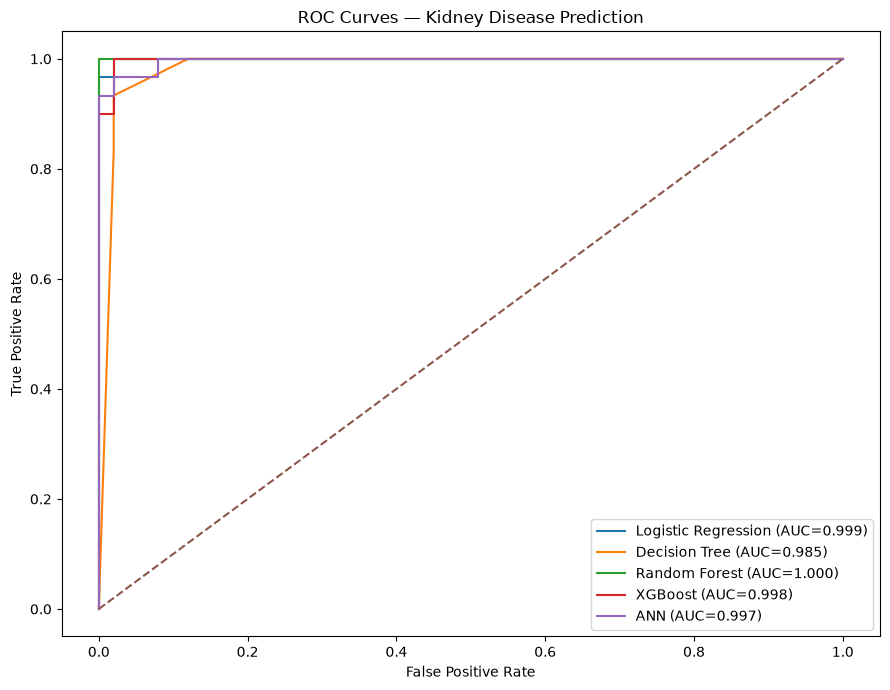

In [162]:
plt.figure(figsize=(9, 7))

for model_name, model in best_estimators.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_value = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — Kidney Disease Prediction"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "roc_curves_all_models.png"
    ),
    dpi=300
)

plt.show()


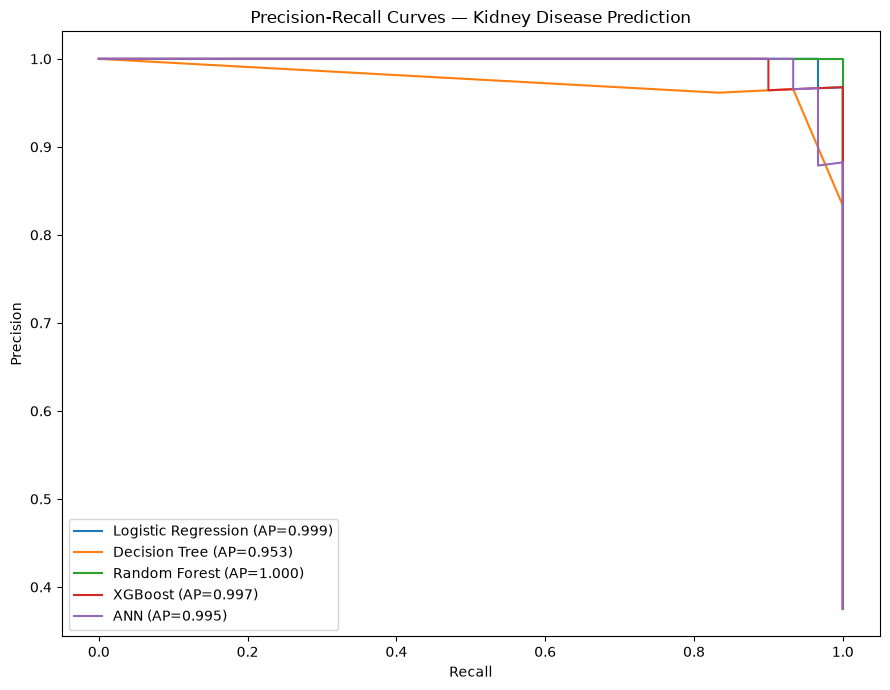

In [163]:
plt.figure(figsize=(9, 7))

for model_name, model in best_estimators.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            y_prob
        )
    )

    pr_auc_value = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (AP={pr_auc_value:.3f})"
    )


plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — Kidney Disease Prediction"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "precision_recall_curves_all_models.png"
    ),
    dpi=300
)

plt.show()



In [177]:
print(results_df)
print(results_df.columns.tolist())

Empty DataFrame
Columns: []
Index: []
[]


In [178]:
results_df = pd.DataFrame(classification_reports).T

print(results_df)
print(results_df.columns.tolist())

                     accuracy  precision    recall        f1   roc_auc  \
Logistic Regression     0.975        1.0  0.933333  0.965517  0.996667   
Decision Tree           0.975        1.0  0.933333  0.965517  0.996667   
Random Forest           0.975        1.0  0.933333  0.965517  0.996667   
XGBoost                 0.975        1.0  0.933333  0.965517  0.996667   
ANN                     0.975        1.0  0.933333  0.965517  0.996667   

                       pr_auc  specificity       npv  balanced_accuracy  \
Logistic Regression  0.994967          1.0  0.961538           0.966667   
Decision Tree        0.994967          1.0  0.961538           0.966667   
Random Forest        0.994967          1.0  0.961538           0.966667   
XGBoost              0.994967          1.0  0.961538           0.966667   
ANN                  0.994967          1.0  0.961538           0.966667   

                          mcc  brier_score  
Logistic Regression  0.947331     0.018176  
Decision Tree 

In [179]:
roc_values = results_df["roc_auc"].sort_values(ascending=False)

In [180]:
results_df = pd.DataFrame(classification_reports).T

results_df = results_df.rename(
    columns={"roc_auc": "ROC-AUC"}
)

roc_values = results_df["ROC-AUC"].sort_values(ascending=False)

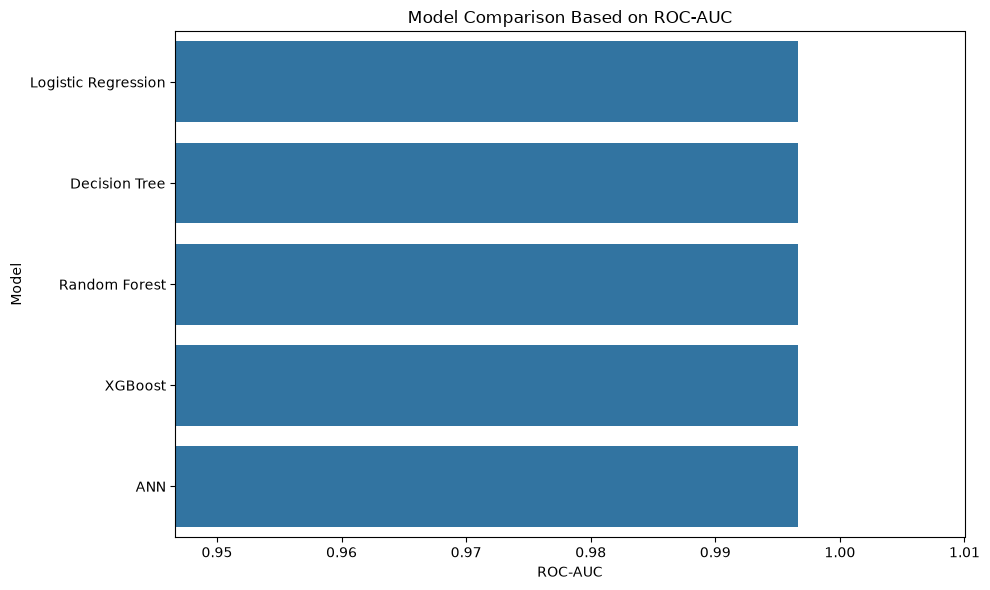

In [181]:
plt.figure(figsize=(10, 6))

roc_values = results_df["ROC-AUC"].sort_values(ascending=False)

sns.barplot(x=roc_values.values, y=roc_values.index)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Model Comparison Based on ROC-AUC")

plt.xlim(max(0, roc_values.min() - 0.05), 1.01)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "model_comparison_roc_auc.png"),
    dpi=300
)

plt.show()

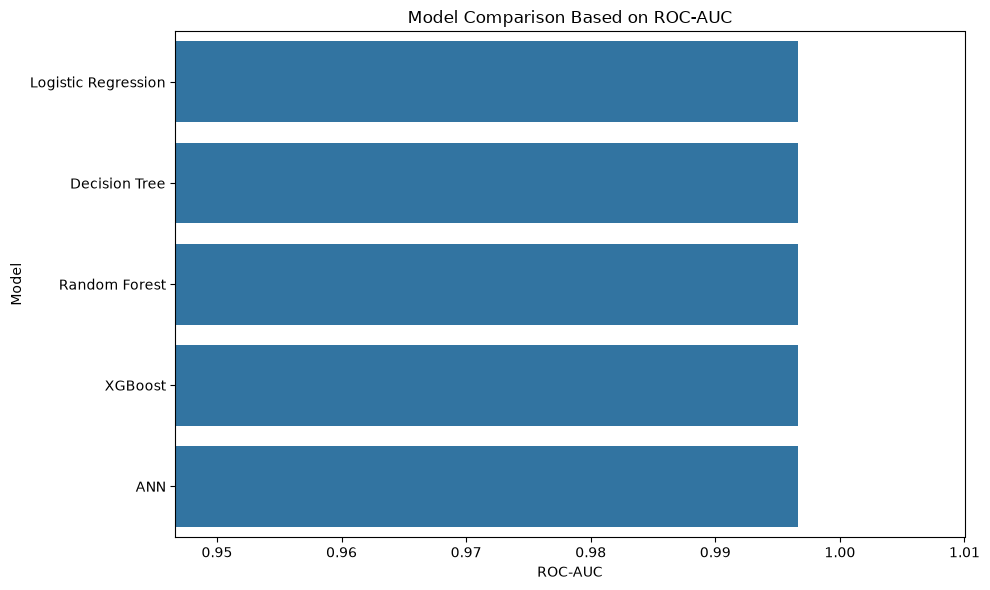

In [182]:
plt.figure(figsize=(10, 6))

roc_values = results_df["ROC-AUC"].sort_values(ascending=False)

sns.barplot(x=roc_values.values, y=roc_values.index)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Model Comparison Based on ROC-AUC")

plt.xlim(max(0, roc_values.min() - 0.05), 1.01)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "model_comparison_roc_auc.png"),
    dpi=300
)

plt.show()


In [196]:
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE — XGBOOST")
print("=" * 70)

xgb_model = best_estimators["XGBoost"]

permutation = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation.importances_mean,
    "Importance_SD": permutation.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

print(permutation_df.head(20))

permutation_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_permutation_importance.csv"
    ),
    index=False
)


PERMUTATION IMPORTANCE — XGBOOST
   Feature  Importance_Mean  Importance_SD
14    hemo         0.087933       0.022247
2       sg         0.039367       0.011990
11      sc         0.013100       0.007767
3       al         0.004933       0.003395
1       bp         0.000000       0.000000
20     cad         0.000000       0.000000
19      dm         0.000000       0.000000
18     htn         0.000000       0.000000
17      rc         0.000000       0.000000
16      wc         0.000000       0.000000
15     pcv         0.000000       0.000000
13     pot         0.000000       0.000000
23     ane         0.000000       0.000000
22      pe         0.000000       0.000000
10      bu         0.000000       0.000000
9      bgr         0.000000       0.000000
8       ba         0.000000       0.000000
7      pcc         0.000000       0.000000
6       pc         0.000000       0.000000
5      rbc         0.000000       0.000000


In [184]:
xgb_classifier = xgb_model.named_steps["model"]

xgb_importance = xgb_classifier.feature_importances_

xgb_feature_importance_df = pd.DataFrame({
    "Feature": feature_names_after_preprocessing,
    "Importance": xgb_importance
}).sort_values(
    "Importance",
    ascending=False
)

print("\nXGBoost Feature Importance:")
print(xgb_feature_importance_df.head(20))

xgb_feature_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_feature_importance.csv"
    ),
    index=False
)


XGBoost Feature Importance:
                  Feature  Importance
10          numeric__hemo    0.595559
2             numeric__sg    0.168210
3             numeric__al    0.096025
185   categorical__htn_no    0.090576
7             numeric__sc    0.037495
0            numeric__age    0.008458
8            numeric__sod    0.003676
129  categorical__wc_9000    0.000000
128  categorical__wc_8800    0.000000
130  categorical__wc_9100    0.000000
127  categorical__wc_8600    0.000000
131  categorical__wc_9200    0.000000
132  categorical__wc_9300    0.000000
133  categorical__wc_9400    0.000000
134  categorical__wc_9500    0.000000
135  categorical__wc_9600    0.000000
136  categorical__wc_9700    0.000000
139   categorical__rc_2.1    0.000000
137  categorical__wc_9800    0.000000
138  categorical__wc_9900    0.000000


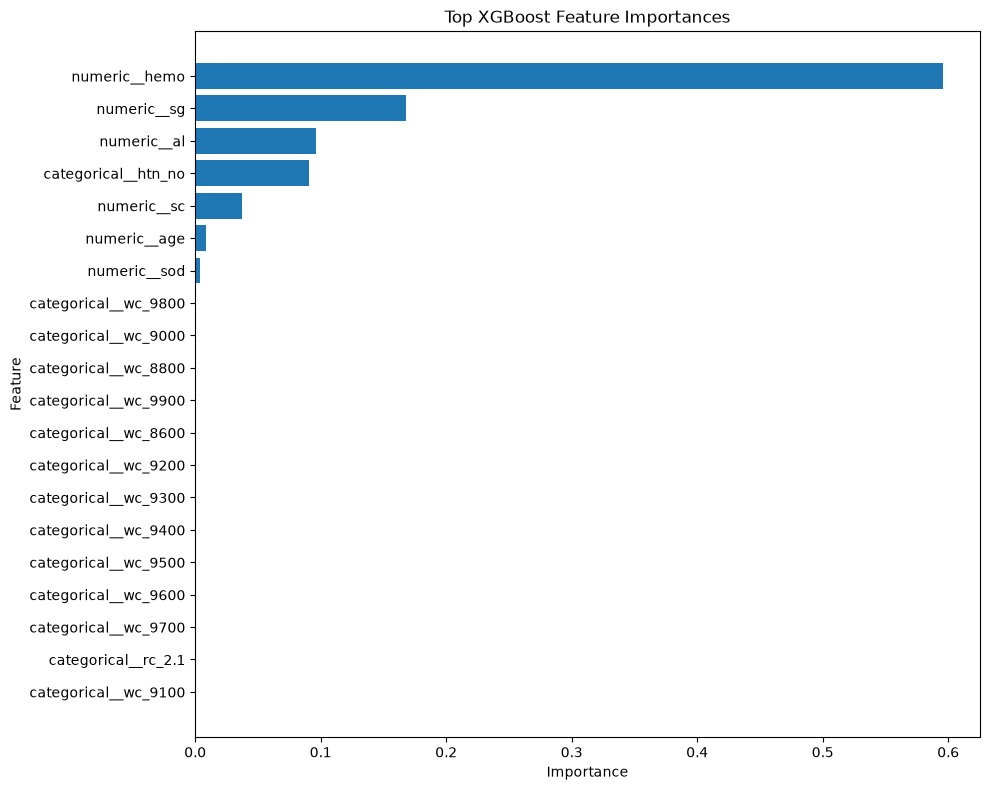

In [185]:
top_features = (
    xgb_feature_importance_df
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importances")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_feature_importance.png"
    ),
    dpi=300
)

plt.show()


SHAP EXPLAINABILITY


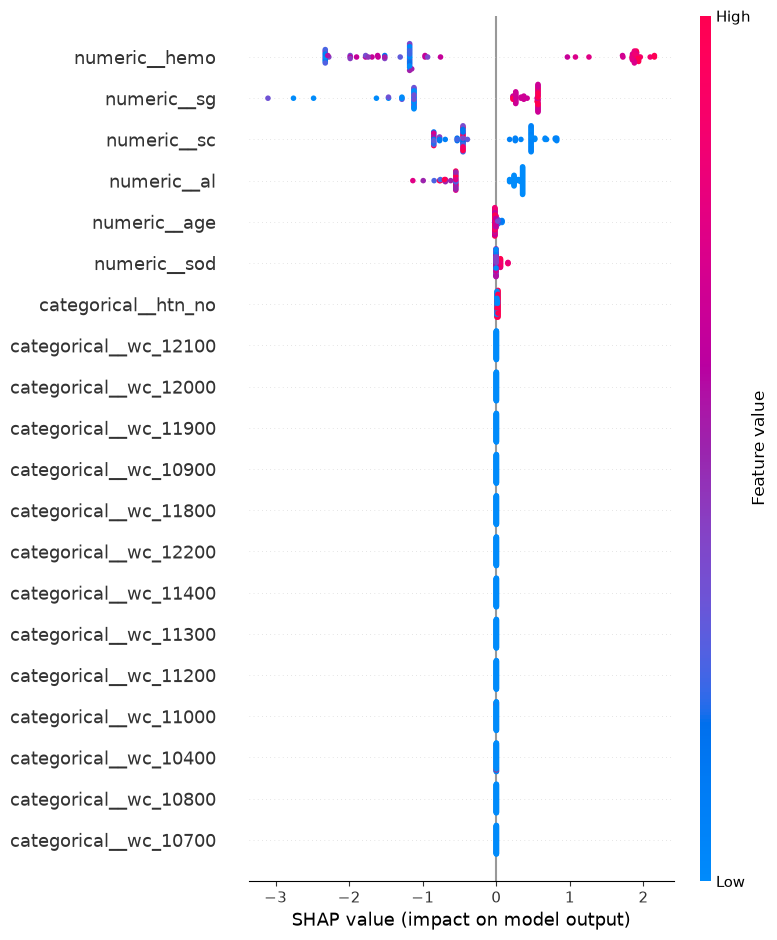


Top SHAP Features:
                  Feature  Mean_Absolute_SHAP
10          numeric__hemo            1.678616
2             numeric__sg            0.777241
7             numeric__sc            0.559425
3             numeric__al            0.437785
0            numeric__age            0.021253
8            numeric__sod            0.019351
185   categorical__htn_no            0.015092
129  categorical__wc_9000            0.000000
128  categorical__wc_8800            0.000000
130  categorical__wc_9100            0.000000
127  categorical__wc_8600            0.000000
131  categorical__wc_9200            0.000000
132  categorical__wc_9300            0.000000
133  categorical__wc_9400            0.000000
134  categorical__wc_9500            0.000000
135  categorical__wc_9600            0.000000
136  categorical__wc_9700            0.000000
139   categorical__rc_2.1            0.000000
137  categorical__wc_9800            0.000000
138  categorical__wc_9900            0.000000


In [186]:
print("\n" + "=" * 70)
print("SHAP EXPLAINABILITY")
print("=" * 70)

try:

    preprocessor_fitted = (
        xgb_model
        .named_steps["preprocessor"]
    )

    xgb_classifier = (
        xgb_model
        .named_steps["model"]
    )

    X_test_transformed = (
        preprocessor_fitted.transform(
            X_test
        )
    )

    if hasattr(
        X_test_transformed,
        "toarray"
    ):

        X_test_transformed = (
            X_test_transformed.toarray()
        )


    explainer = shap.TreeExplainer(
        xgb_classifier
    )

    shap_values = explainer.shap_values(
        X_test_transformed
    )


    plt.figure()

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names_after_preprocessing,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_summary_plot.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    shap_importance = np.abs(
        shap_values
    ).mean(axis=0)

    shap_df = pd.DataFrame({

        "Feature":
            feature_names_after_preprocessing,

        "Mean_Absolute_SHAP":
            shap_importance

    }).sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    shap_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "shap_feature_importance.csv"
        ),
        index=False
    )

    print("\nTop SHAP Features:")

    print(
        shap_df.head(20)
    )

except Exception as e:

    print(
        "\nSHAP analysis could not be completed:"
    )

    print(e)

In [ ]:
print("\n" + "=" * 70)
print("SAVING MODELS")
print("=" * 70)

for model_name, model in best_estimators.items():

    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        + "_pipeline.pkl"
    )

    joblib.dump(
        model,
        os.path.join(
            OUTPUT_DIR,
            filename
        )
    )

    print(
        "Saved:",
        filename
    )



SAVING MODELS
Saved: logistic_regression_pipeline.pkl


In [167]:
joblib.dump( label_encoder,  os.path.join(   OUTPUT_DIR, "label_encoder.pkl"
    )
)

['kidney_research_outputs/label_encoder.pkl']

In [192]:
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE — XGBOOST")
print("=" * 70)

xgb_model = best_estimators["XGBoost"]

permutation = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation.importances_mean,
    "Importance_SD": permutation.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

print(permutation_df.head(20))

permutation_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_permutation_importance.csv"
    ),
    index=False
)


PERMUTATION IMPORTANCE — XGBOOST
   Feature  Importance_Mean  Importance_SD
14    hemo         0.087933       0.022247
2       sg         0.039367       0.011990
11      sc         0.013100       0.007767
3       al         0.004933       0.003395
1       bp         0.000000       0.000000
20     cad         0.000000       0.000000
19      dm         0.000000       0.000000
18     htn         0.000000       0.000000
17      rc         0.000000       0.000000
16      wc         0.000000       0.000000
15     pcv         0.000000       0.000000
13     pot         0.000000       0.000000
23     ane         0.000000       0.000000
22      pe         0.000000       0.000000
10      bu         0.000000       0.000000
9      bgr         0.000000       0.000000
8       ba         0.000000       0.000000
7      pcc         0.000000       0.000000
6       pc         0.000000       0.000000
5      rbc         0.000000       0.000000


In [193]:
excel_path = os.path.join(
    OUTPUT_DIR,
    "heart_research_results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="Test Metrics"
    )

    cv_df.to_excel(
        writer,
        sheet_name="Cross Validation",
        index=False
    )

    best_params_df.to_excel(
        writer,
        sheet_name="Best Parameters"
    )

    if len(numeric_columns) > 0:
        numeric_summary.to_excel(
            writer,
            sheet_name="Numeric Summary"
        )

    missing_summary.to_frame(
        "Missing_Count"
    ).to_excel(
        writer,
        sheet_name="Missing Values"
    )

    if len(numeric_columns) > 1:
        target_correlations.to_frame(
            "Correlation"
        ).to_excel(
            writer,
            sheet_name="Target Correlations"
        )

    permutation_df.to_excel(
        writer,
        sheet_name="Permutation Importance",
        index=False
    )

    xgb_feature_importance_df.to_excel(
        writer,
        sheet_name="XGB Importance",
        index=False
    )

    try:
        shap_df.to_excel(
            writer,
            sheet_name="SHAP Importance",
            index=False
        )
    except NameError:
        pass

print(f"Research results saved to:\n{excel_path}")


Research results saved to:
kidney_research_outputs/heart_research_results.xlsx


In [198]:
# ============================================================
# 35. CLASSIFICATION REPORT
# ============================================================

classification_reports = {}

for model_name,result in test_results.items():
    report = classification_report(y_test,result["y_pred"],target_names=label_encoder.classes_,zero_division=0)
    classification_reports[model_name] = report
    print("\n"+model_name); print(report)


In [199]:
# ============================================================
# 47. SAVE CLASSIFICATION REPORTS
# ============================================================

reports_path = os.path.join(OUTPUT_DIR,"classification_reports.txt")

with open(reports_path,"w",encoding="utf-8") as file:
    for model_name,report in classification_reports.items():
        file.write("\n"+"="*70+"\n"+model_name+"\n"+"="*70+"\n")
        if isinstance(report,dict):
            file.write(classification_report(y_test,test_results[model_name]["y_pred"],target_names=label_encoder.classes_,zero_division=0))
        else:
            file.write(str(report))
        file.write("\n")

print(f"Classification reports saved to:\n{reports_path}")

Classification reports saved to:
kidney_research_outputs/classification_reports.txt


In [170]:
print("\n" + "=" * 70)
print("RESEARCH SUMMARY")
print("=" * 70)

print("\nDataset:")
print(
    f"{df.shape[0]} samples, "
    f"{X.shape[1]} predictor variables"
)

print("\nTarget:")
print(
    "Kidney Disease Classification"
)

print("\nModels Evaluated:")

for model_name in models.keys():

    print(
        "•",
        model_name
    )

print("\nEvaluation:")
print(
    "80/20 stratified hold-out test set"
)

print(
    "5-fold stratified cross-validation"
)

print(
    "Hyperparameter optimization using GridSearchCV"
)

print(
    "ROC-AUC used as model-selection metric"
)

print("\nMetrics:")

print(
    "Accuracy, Precision, Recall, F1, "
    "ROC-AUC, PR-AUC, Specificity, NPV, "
    "Balanced Accuracy, MCC, Brier Score"
)

print("\nExplainability:")

print(
    "XGBoost feature importance"
)

print(
    "Permutation importance"
)

print(
    "SHAP"
)

print("\nOutputs saved to:")

print(
    OUTPUT_DIR
)

print("\n" + "=" * 70)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)



RESEARCH SUMMARY

Dataset:
400 samples, 24 predictor variables

Target:
Kidney Disease Classification

Models Evaluated:
• Logistic Regression
• Decision Tree
• Random Forest
• XGBoost
• ANN

Evaluation:
80/20 stratified hold-out test set
5-fold stratified cross-validation
Hyperparameter optimization using GridSearchCV
ROC-AUC used as model-selection metric

Metrics:
Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Specificity, NPV, Balanced Accuracy, MCC, Brier Score

Explainability:
XGBoost feature importance
Permutation importance
SHAP

Outputs saved to:
kidney_research_outputs

PIPELINE COMPLETED SUCCESSFULLY


In [171]:
print(
    """
RESEARCH NOTE:

The dataset is relatively small (approximately 400 records),
so extremely high performance must NOT automatically be interpreted
as evidence of clinical-grade performance.

Before using these results in a research paper, additionally consider:

1. Independent external validation.
2. Nested cross-validation for unbiased model comparison.
3. 95% confidence intervals using bootstrap resampling.
4. Calibration curves and calibration metrics.
5. Statistical comparison of model performance.
6. Detailed leakage audit.
7. Class imbalance analysis.
8. Clinical interpretation of important features.
9. Reproducibility through fixed random seeds.
10. Transparent reporting of preprocessing and hyperparameters.

The model with the highest score on one metric should not
automatically be described as scientifically superior.
"""
)


RESEARCH NOTE:

The dataset is relatively small (approximately 400 records),
so extremely high performance must NOT automatically be interpreted
as evidence of clinical-grade performance.

Before using these results in a research paper, additionally consider:

1. Independent external validation.
2. Nested cross-validation for unbiased model comparison.
3. 95% confidence intervals using bootstrap resampling.
4. Calibration curves and calibration metrics.
5. Statistical comparison of model performance.
6. Detailed leakage audit.
7. Class imbalance analysis.
8. Clinical interpretation of important features.
9. Reproducibility through fixed random seeds.
10. Transparent reporting of preprocessing and hyperparameters.

The model with the highest score on one metric should not
automatically be described as scientifically superior.

